In [ ]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

GPU: Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset, Dataset
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm
import os
import random
import numpy as np
from PIL import Image

# 1. Configuration
class Config:
    seed = 42
    image_encoder_name = "facebook/dinov2-small"
    text_encoder_name = "bert-base-uncased"
    input_size = (224, 224)
    projection_dim = 768    # Match BERT's 768 output dim
    num_epochs = 20
    batch_size = 32
    learning_rate = 1e-5    # Lower LR for fine-tuning vision backbone
    stop_at_accuracy = 0.90 # Stop training if test accuracy > 90%
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(Config.seed)
print(f"Using device: {Config.device}")

Using device: cuda


In [ ]:
# ==========================================
# 2. Text Encoder (Frozen BERT)
class BertTextEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)
        for param in self.bert.parameters():
            param.requires_grad = False

    def forward(self, class_names):
        # Create prompts: "a photo of a [class]"
        prompts = [f"a photo of a {c.replace('_', ' ')}" for c in class_names]
        inputs = self.tokenizer(prompts, padding=True, truncation=True, return_tensors="pt").to(Config.device)
        outputs = self.bert(**inputs)
        # Use [CLS] token and normalize
        embeddings = outputs.last_hidden_state[:, 0, :]
        return embeddings / embeddings.norm(dim=-1, keepdim=True)

# 3. Image Encoder (DINOv2 + Projection)
class DinoV2Encoder(nn.Module):
    def __init__(self, model_name, projection_dim):
        super().__init__()
        self.dinov2 = AutoModel.from_pretrained(model_name)
        # dinov2-small output is 384. Project to 768 to match BERT.
        self.projection = nn.Linear(384, projection_dim)

    def forward(self, x):
        outputs = self.dinov2(pixel_values=x)
        patch_embeddings = outputs.last_hidden_state[:, 0, :]
        projected = self.projection(patch_embeddings)
        return projected / projected.norm(dim=-1, keepdim=True)

# Helper for Dataset indexing
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

    # forward method typically defines how the model generates outputs (features/logits)
    # during training with a contrastive loss

In [ ]:
# 4. Data Preparation (FIXED for Grayscale Images)

# We add a Lambda transform to convert images to RGB to handle grayscale entries
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')), # Fix: Force 3 channels
    transforms.Resize(Config.input_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')), # Fix: Force 3 channels
    transforms.Resize(Config.input_size),
    transforms.CenterCrop(Config.input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Re-run this block to refresh the datasets
full_dataset = datasets.Caltech101(root='./data', download=True)

# Important: Caltech101 labels are 0-indexed, but the dataset sometimes
# includes a "background" class depending on the version.
# We ensure indices are handled correctly.
indices = list(range(len(full_dataset)))
random.shuffle(indices)
split = int(0.8 * len(full_dataset))

train_data = ApplyTransform(Subset(full_dataset, indices[:split]), train_transform)
test_data = ApplyTransform(Subset(full_dataset, indices[split:]), test_transform)

train_loader = DataLoader(train_data, batch_size=Config.batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=Config.batch_size, shuffle=False)

classes = full_dataset.categories
print(f"Loaded {len(classes)} classes. Train: {len(train_data)}, Test: {len(test_data)}")

Loaded 101 classes. Train: 6941, Test: 1736


In [ ]:
# 5. Initialization
text_model = BertTextEncoder(Config.text_encoder_name).to(Config.device)
image_model = DinoV2Encoder(Config.image_encoder_name, Config.projection_dim).to(Config.device)
optimizer = optim.AdamW(image_model.parameters(), lr=Config.learning_rate)
criterion = nn.CrossEntropyLoss()

# Precompute text embeddings for all classes for evaluation
with torch.no_grad():
    class_embeddings = text_model(classes) # (101, 768)

def evaluate():
    image_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(Config.device), labels.to(Config.device)
            img_features = image_model(imgs)
            logits = (100.0 * img_features @ class_embeddings.t())
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 6. Training Loop
print("Starting training...")
for epoch in range(Config.num_epochs):
    image_model.train()
    total_loss = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs = imgs.to(Config.device)
        # Get target text embeddings for this batch
        batch_class_names = [classes[l] for l in labels]
        with torch.no_grad():
            target_text_features = text_model(batch_class_names)

        img_features = image_model(imgs)

        # Contrastive similarity loss
        logits = (100.0 * img_features @ target_text_features.t())
        targets = torch.arange(imgs.size(0)).to(Config.device)
        loss = criterion(logits, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Accuracy Checks
    test_acc = evaluate()
    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {test_acc:.4f}")

    if test_acc >= Config.stop_at_accuracy:
        print(f"Reached {Config.stop_at_accuracy*100}% accuracy. Stopping early.")
        break

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Starting training...


Epoch 1: 100%|██████████| 217/217 [01:57<00:00,  1.84it/s]


Epoch 1 | Loss: 1.2096 | Test Acc: 0.9073
Reached 90.0% accuracy. Stopping early.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save the model's learned parameters
torch.save(image_model.state_dict(), 'dinov2_caltech_weights.pth')
print("Model weights saved successfully!")

Model weights saved successfully!


In [ ]:
torch.save(image_model.state_dict(), '/content/drive/MyDrive/dinov2_caltech_weights.pth')

In [ ]:
# 1. Initialize the architecture (must be the same as training)
image_model = DinoV2Encoder(Config.image_encoder_name, Config.projection_dim).to(Config.device)

# 2. Load the saved weights
weights_path = 'dinov2_caltech_weights.pth'
image_model.load_state_dict(torch.load(weights_path, map_location=Config.device))

# 3. Set to evaluation mode
image_model.eval()
print("Weights loaded! You can now run your zero-shot tests.")

Please upload an image to test...


Saving indian-man-7061278_1280.jpg to indian-man-7061278_1280 (2).jpg


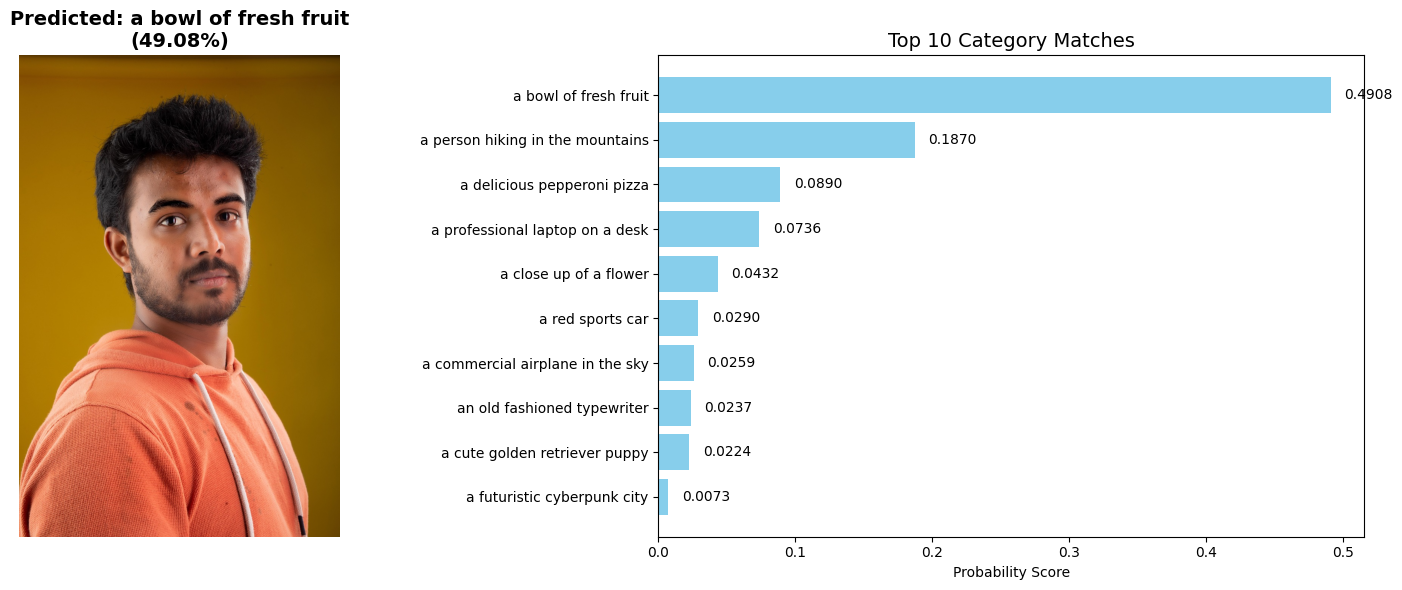

In [ ]:
# 7. Zero-Shot Test with Top 10 Score Visualization
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def test_unseen_top_10(image_path, candidate_labels):
    # 1. Load and process the image
    raw_image = Image.open(image_path).convert("RGB")
    img_tensor = test_transform(raw_image).unsqueeze(0).to(Config.device)

    # 2. Run Inference
    image_model.eval()
    with torch.no_grad():
        # Encode the candidate labels into the shared embedding space
        candidate_embeddings = text_model(candidate_labels)
        img_features = image_model(img_tensor)

        # Calculate cosine similarity and convert to probabilities
        logits = (100.0 * img_features @ candidate_embeddings.t())
        probs = logits.softmax(dim=-1).squeeze()

    # 3. Extract Top 10 (or fewer if candidate_labels is shorter)
    top_k = min(10, len(candidate_labels))
    top_probs, top_indices = torch.topk(probs, top_k)

    # Move to CPU for plotting
    top_probs = top_probs.cpu().numpy()
    top_labels = [candidate_labels[i] for i in top_indices.cpu().numpy()]

    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Left side: The Image
    ax1.imshow(raw_image)
    ax1.set_title(f"Predicted: {top_labels[0]}\n({top_probs[0]*100:.2f}%)", fontsize=14, fontweight='bold')
    ax1.axis('off')

    # Right side: The Top 10 Scores
    y_pos = np.arange(len(top_labels))
    bars = ax2.barh(y_pos, top_probs, align='center', color='skyblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(top_labels)
    ax2.invert_yaxis()  # Put the highest score at the top
    ax2.set_xlabel('Probability Score')
    ax2.set_title('Top 10 Category Matches', fontsize=14)

    # Add text labels on the bars
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}', va='center')

    plt.tight_layout()
    plt.show()

# --- RUN THE TEST ---
try:
    print("Please upload an image to test...")
    uploaded = files.upload()
    if uploaded:
        filename = list(uploaded.keys())[0]

        # You can add as many labels as you want here!
        # The model will rank them based on visual similarity.
        my_test_labels = [
            "a futuristic cyberpunk city",
            "a cute golden retriever puppy",
            "a professional laptop on a desk",
            "a delicious pepperoni pizza",
            "a person hiking in the mountains",
            "a red sports car",
            "a close up of a flower",
            "a view of the ocean at sunset",
            "a commercial airplane in the sky",
            "a bowl of fresh fruit",
            "an old fashioned typewriter",
            "a modern smartphone"
        ]

        test_unseen_top_10(filename, my_test_labels)
except Exception as e:
    print(f"Error: {e}. Ensure you have trained the model or loaded weights first.")